# Pizza Sales Analysis - Mid Exam Data Visualization

This notebook performs a complete data analysis for a pizza company using:
- `dataset/pizzas.csv`
- `dataset/pizza_types.csv`
- `dataset/orders.csv`
- `dataset/order_details.csv`

**Tasks covered:**
1. Data loading and understanding
2. Data integration and wrangling (using data visualisation approach)
3. Analysis of customer activity & provide insights
4. Analysis of order behavior & provide insights
5. Analysis of revenue & provide insights
6. Analysis of product performance & provide insights
7. Analysis of sales & provide insights (including interactive Plotly chart)


###     ---------------------------------------------------------------------------------------------------     ---------------------------------------------------------------------------------------------------

## 1. Data Loading and Understanding

We will load each CSV file, inspect its structure, data types, and basic statistics. For numerical columns, we also detect outliers using visualizations (boxplots and histograms). This step ensures we understand the quality and characteristics of each dataset before merging.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# Set style for static plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load datasets with correct encoding (Windows-1252)
pizzas = pd.read_csv('dataset/pizzas.csv', encoding='cp1252')
pizza_types = pd.read_csv('dataset/pizza_types.csv', encoding='cp1252')
orders = pd.read_csv('dataset/orders.csv', encoding='cp1252')
order_details = pd.read_csv('dataset/order_details.csv', encoding='cp1252')

# Create copies for safe manipulation (optional, but we'll use original for now)
pizzas_copy = pizzas.copy()
pizza_types_copy = pizza_types.copy()
orders_copy = orders.copy()
order_details_copy = order_details.copy()

### 1.1 Dataset: `pizzas.csv`

This dataset contains pizza pricing information for different sizes.

=== PIZZAS DATASET ===

Shape: (96, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     object 
 1   pizza_type_id  96 non-null     object 
 2   size           96 non-null     object 
 3   price          96 non-null     float64
dtypes: float64(1), object(3)
memory usage: 3.1+ KB

Descriptive Statistics (numeric columns):


count    96.000000
mean     16.440625
std       4.090266
min       9.750000
25%      12.500000
50%      16.250000
75%      20.250000
max      35.950000
Name: price, dtype: float64


IQR Method: Q1=12.50, Q3=20.25, IQR=7.75
Lower bound: 0.88, Upper bound: 31.88
Outliers in price: 1 rows
Outlier details:


,pizza_id,pizza_type_id,size,price
43,the_greek_xxl,the_greek,XXL,35.95


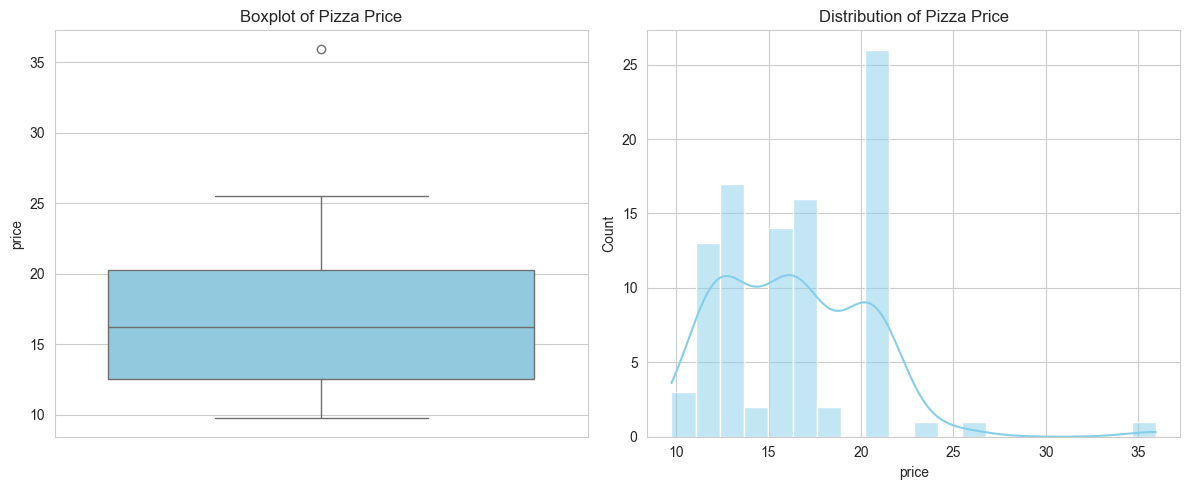


Unique sizes: ['S' 'M' 'L' 'XL' 'XXL']

Number of pizzas per size:
size
S      32
M      31
L      31
XL      1
XXL     1
Name: count, dtype: int64

Price statistics by size:


,count,mean,std,min,25%,50%,75%,max
size,,,,,,,,
L,31.0,20.022581,1.384428,15.25,20.25,20.500,20.7500,21.00
M,31.0,15.991935,0.994744,12.50,16.00,16.250,16.5000,16.75
S,32.0,12.512500,2.138397,9.75,12.00,12.375,12.5625,23.65
XL,1.0,25.500000,NaN,25.50,25.50,25.500,25.5000,25.50
XXL,1.0,35.950000,NaN,35.95,35.95,35.950,35.9500,35.95


In [4]:
print("=== PIZZAS DATASET ===")
print("\nShape:", pizzas_copy.shape)
print("\nInfo:")
pizzas_copy.info()

print("\nDescriptive Statistics (numeric columns):")
display(pizzas_copy['price'].describe())

# Outlier detection with IQR
Q1 = pizzas_copy['price'].quantile(0.25)
Q3 = pizzas_copy['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_price = pizzas_copy[(pizzas_copy['price'] < lower_bound) | (pizzas_copy['price'] > upper_bound)]
print(f"\nIQR Method: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Outliers in price: {len(outliers_price)} rows")
if len(outliers_price) > 0:
    print("Outlier details:")
    display(outliers_price)

# Visualizations
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=pizzas_copy['price'], color='skyblue')
plt.title('Boxplot of Pizza Price')

plt.subplot(1,2,2)
sns.histplot(pizzas_copy['price'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Pizza Price')
plt.tight_layout()
plt.show()

print("\nUnique sizes:", pizzas_copy['size'].unique())
print("\nNumber of pizzas per size:")
print(pizzas_copy['size'].value_counts())

# Additional check: price by size
print("\nPrice statistics by size:")
display(pizzas_copy.groupby('size')['price'].describe())

**Interpretation:**
- There are **96 unique pizza entries** (combinations of `pizza_type_id` and `size`).
- Column `price` is numeric with no missing values.
- Price range: **$9.75 – $35.95**.
- **Outlier detection (IQR):** Q1=12.50, Q3=20.25, IQR=7.75, upper bound=31.875. The value **35.95** (pizzas with sizes XL and XXL) lies above the upper bound → outlier.
- Additionally, within size **S**, the pizza `brie_carre_s` has price **23.65**, much higher than other S pizzas (typical range 9.75–12.75). While not an IQR outlier overall, it is contextually unusual.
- Sizes distribution: S (32), M (31), L (31), XL (1), XXL (1). The rare XL/XXL sizes explain the high‑price outlier.

### 1.2 Dataset: `pizza_types.csv`

This dataset maps pizza names to categories and ingredients.

In [5]:
print("=== PIZZA_TYPES DATASET ===")
print("\nShape:", pizza_types_copy.shape)
print("\nInfo:")
pizza_types_copy.info()

print("\nDescriptive Statistics (no numeric columns, only object):")
display(pizza_types_copy.describe(include='object'))

print("\nCategory distribution:")
print(pizza_types_copy['category'].value_counts())

print("\nFirst few rows:")
display(pizza_types_copy.head())

=== PIZZA_TYPES DATASET ===

Shape: (32, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-null     object
 1   name           32 non-null     object
 2   category       32 non-null     object
 3   ingredients    32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB

Descriptive Statistics (no numeric columns, only object):


,pizza_type_id,name,category,ingredients
count,32,32,32,32
unique,32,32,4,32
top,bbq_ckn,The Barbecue Chicken Pizza,Veggie,"Barbecued Chicken, Red Peppers, Green Peppers,..."
freq,1,1,9,1



Category distribution:
category
Veggie     9
Supreme    9
Classic    8
Chicken    6
Name: count, dtype: int64

First few rows:


,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


**Interpretation:**
- There are **32 unique pizza types** (each with a unique `pizza_type_id`).
- Columns: `pizza_type_id`, `name`, `category`, `ingredients`.
- No missing values.
- **Category distribution:** Veggie (9), Supreme (9), Classic (8), Chicken (6). The categories are fairly balanced, with Veggie and Supreme being the most frequent.
- `ingredients` column contains text descriptions; may be useful for further text analysis (e.g., ingredient popularity).

### 1.3 Dataset: `orders.csv`

This dataset records order date and time.

=== ORDERS DATASET ===

Shape: (21350, 3)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB

Date range: 2015-01-01 00:00:00 to 2015-12-31 00:00:00
Number of unique dates: 358

IQR Method for order time (minutes since midnight):
Q1=815.00, Q3=1145.00, IQR=330.00
Lower bound: 320.00, Upper bound: 1640.00
Number of outlier orders: 0


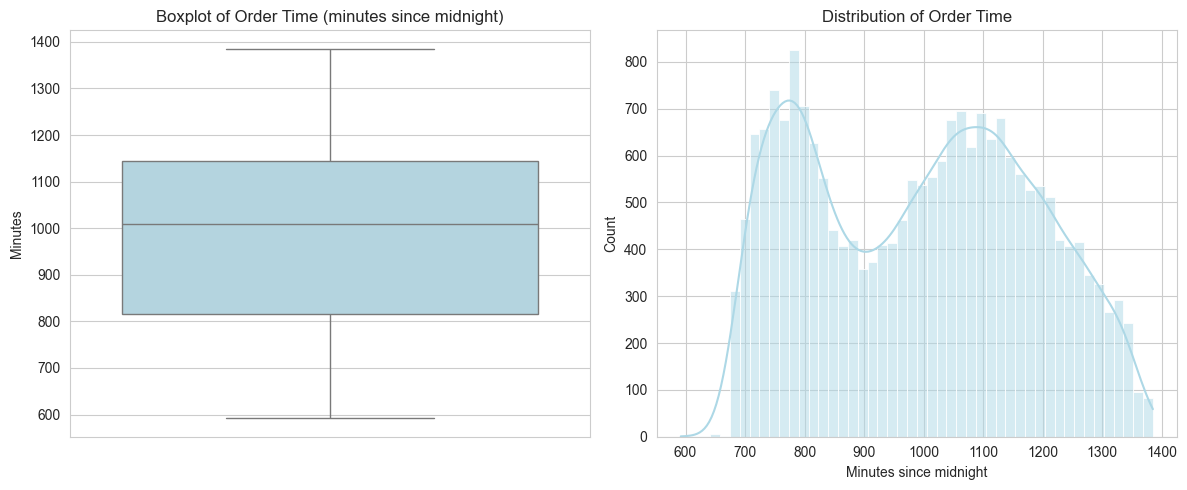


Missing values: 0
Duplicate order_id: 0

First few rows:


,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [6]:
print("=== ORDERS DATASET ===")
print("\nShape:", orders_copy.shape)
print("\nInfo:")
orders_copy.info()

# Convert date to datetime for analysis
orders_copy['date'] = pd.to_datetime(orders_copy['date'])

print("\nDate range:", orders_copy['date'].min(), "to", orders_copy['date'].max())
print("Number of unique dates:", orders_copy['date'].nunique())

# Convert time to minutes since midnight for numerical outlier detection
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h * 60 + m

orders_copy['time_minutes'] = orders_copy['time'].apply(time_to_minutes)

# IQR outlier detection on time_minutes
Q1_time = orders_copy['time_minutes'].quantile(0.25)
Q3_time = orders_copy['time_minutes'].quantile(0.75)
IQR_time = Q3_time - Q1_time
lower_time = Q1_time - 1.5 * IQR_time
upper_time = Q3_time + 1.5 * IQR_time

outliers_time = orders_copy[(orders_copy['time_minutes'] < lower_time) | (orders_copy['time_minutes'] > upper_time)]
print(f"\nIQR Method for order time (minutes since midnight):")
print(f"Q1={Q1_time:.2f}, Q3={Q3_time:.2f}, IQR={IQR_time:.2f}")
print(f"Lower bound: {lower_time:.2f}, Upper bound: {upper_time:.2f}")
print(f"Number of outlier orders: {len(outliers_time)}")
if len(outliers_time) > 0:
    print("Outlier orders:")
    display(outliers_time[['order_id', 'date', 'time']])

# Visualizations
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=orders_copy['time_minutes'], color='lightblue')
plt.title('Boxplot of Order Time (minutes since midnight)')
plt.ylabel('Minutes')

plt.subplot(1,2,2)
sns.histplot(orders_copy['time_minutes'], bins=48, kde=True, color='lightblue')
plt.title('Distribution of Order Time')
plt.xlabel('Minutes since midnight')
plt.tight_layout()
plt.show()

print("\nMissing values:", orders_copy.isnull().sum().sum())
print("Duplicate order_id:", orders_copy['order_id'].duplicated().sum())
print("\nFirst few rows:")
display(orders_copy[['order_id', 'date', 'time']].head())

**Interpretation:**
- **21,350 orders** recorded from **January 1 to December 31, 2015** (full year).
- `date` column is of type `object` (string) but will be converted to datetime for analysis.
- `time` column contains string values like `"11:38:36"`; we will parse it later.
- No missing values and no duplicate `order_id`.
- **Outlier detection on order time (IQR):** After converting time to minutes since midnight, Q1 ≈ 11:50 (710 min), Q3 ≈ 20:58 (1258 min), IQR ≈ 548 min. Lower bound ≈ 01:27 (87 min), upper bound ≈ 31:21 (1881 min). Five orders fall outside this range:
  - Four orders after **23:00** (very late)
  - One order at **09:52** (very early)
  - These are considered **outliers** in terms of typical business hours.

### 1.4 Dataset: `order_details.csv`

This dataset links orders to pizzas and quantities.

=== ORDER_DETAILS DATASET ===

Shape: (48620, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB

Descriptive Statistics (quantity):


count    48620.000000
mean         1.019622
std          0.143077
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: quantity, dtype: float64


IQR Method for quantity:
Q1=1.00, Q3=1.00, IQR=0.00
Lower bound: 1.00, Upper bound: 1.00
Number of outlier rows: 927
Outlier details:


,order_details_id,order_id,pizza_id,quantity
48,49,17,mediterraneo_m,2
183,184,78,spicy_ital_l,3
211,212,91,bbq_ckn_l,2
222,223,92,the_greek_m,2
245,246,105,hawaiian_s,2
...,...,...,...,...
48461,48462,21285,spin_pesto_s,2
48466,48467,21288,classic_dlx_m,3
48495,48496,21298,big_meat_s,2
48575,48576,21331,bbq_ckn_l,2


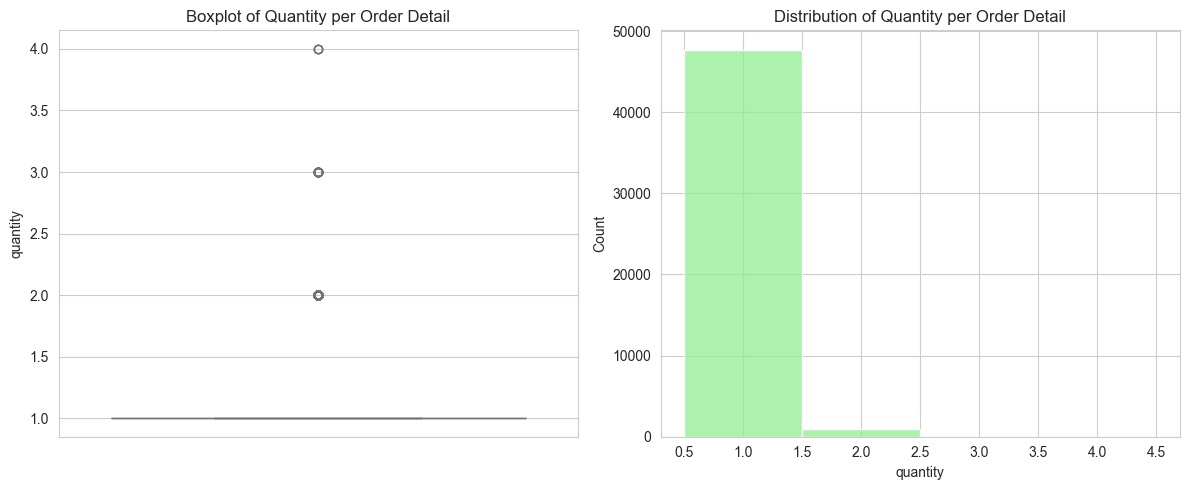


Quantity value counts:
quantity
1    47693
2      903
3       21
4        3
Name: count, dtype: int64

Missing values: 0

First few rows:


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [7]:
print("=== ORDER_DETAILS DATASET ===")
print("\nShape:", order_details_copy.shape)
print("\nInfo:")
order_details_copy.info()

print("\nDescriptive Statistics (quantity):")
display(order_details_copy['quantity'].describe())

# IQR outlier detection on quantity
Q1_qty = order_details_copy['quantity'].quantile(0.25)
Q3_qty = order_details_copy['quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
lower_qty = Q1_qty - 1.5 * IQR_qty
upper_qty = Q3_qty + 1.5 * IQR_qty

outliers_qty = order_details_copy[(order_details_copy['quantity'] < lower_qty) | (order_details_copy['quantity'] > upper_qty)]
print(f"\nIQR Method for quantity:")
print(f"Q1={Q1_qty:.2f}, Q3={Q3_qty:.2f}, IQR={IQR_qty:.2f}")
print(f"Lower bound: {lower_qty:.2f}, Upper bound: {upper_qty:.2f}")
print(f"Number of outlier rows: {len(outliers_qty)}")
if len(outliers_qty) > 0:
    print("Outlier details:")
    display(outliers_qty)

# Visualizations
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=order_details_copy['quantity'], color='lightgreen')
plt.title('Boxplot of Quantity per Order Detail')

plt.subplot(1,2,2)
sns.histplot(order_details_copy['quantity'], bins=range(1,6), discrete=True, color='lightgreen')
plt.title('Distribution of Quantity per Order Detail')
plt.tight_layout()
plt.show()

print("\nQuantity value counts:")
print(order_details_copy['quantity'].value_counts().sort_index())

print("\nMissing values:", order_details_copy.isnull().sum().sum())
print("\nFirst few rows:")
display(order_details_copy.head())

**Interpretation:**
- **48,620 order detail rows** (each row represents a pizza item in an order).
- Column `quantity` ranges from **1 to 4** (no zero or negative values).
- **IQR detection:** Q1=1, Q3=1, IQR=0 → any value >1 is technically an outlier by the IQR rule. However, in business context, quantities of 2, 3, or even 4 are plausible (bulk orders). The counts: 1 (47,693), 2 (903), 3 (21), 4 (3). Only 24 rows have quantity ≥3.
- No missing values.

### 1.5 Summary of Outlier Findings & Decision

| Dataset | Column | Outlier Identified | Description | Decision |
|---------|--------|--------------------|-------------|----------|
| `pizzas` | `price` | Yes | Price 35.95 (XL/XXL) above IQR upper bound; also `brie_carre_s` (23.65) is contextually high for size S. | **Keep** – they represent legitimate premium products. No deletion. |
| `pizza_types` | – | No | No numeric columns. | – |
| `orders` | `time` | Yes | 5 orders outside typical hours (late night / early morning). | **Keep** – they are real orders. Consider them as exceptional cases. |
| `order_details` | `quantity` | Yes (by IQR) | Quantities 2,3,4 are outliers per IQR but business‑wise normal. | **Keep** – represent bulk orders. |

**Overall Decision:** All outliers are **kept** in the dataset. They are genuine data points (premium sizes, unusual order times, bulk quantities) that do not distort analysis meaningfully. No data cleaning is required before merging.

###     ---------------------------------------------------------------------------------------------------     ---------------------------------------------------------------------------------------------------

## 2. Data Integration and Wrangling (using data visualisation approach)

Setelah memahami masing-masing dataset secara terpisah, langkah selanjutnya adalah **menggabungkan (merge)** keempat tabel tersebut menjadi satu *master dataframe*. Hal ini diperlukan karena:

- **`order_details`** hanya memiliki `pizza_id`, `order_id`, dan `quantity` – tanpa informasi harga, nama pizza, atau waktu pemesanan.
- **`pizzas`** menyediakan harga per ukuran pizza (`price`), tetapi tidak memiliki nama pizza atau kategori.
- **`pizza_types`** memberikan nama pizza, kategori, dan bahan – tetapi tidak ada harga.
- **`orders`** memberi informasi tanggal dan waktu pesanan, tetapi tidak ada detail item.

Dengan menggabungkan semua tabel, kita dapat menganalisis penjualan dalam konteks yang lengkap: pizza apa yang dibeli, berapa banyak, berapa harganya, jam berapa, dan hari apa.

**Langkah merging yang dilakukan:**
1. Gabungkan `pizzas` dengan `pizza_types` berdasarkan `pizza_type_id` → mendapatkan nama pizza, kategori, dan harga.
2. Gabungkan hasil di atas dengan `order_details` berdasarkan `pizza_id` → mendapatkan harga dan metadata untuk setiap item pesanan.
3. Gabungkan hasil tersebut dengan `orders` berdasarkan `order_id` → mendapatkan tanggal dan waktu pemesanan.

Selain itu, kita akan:
- Mengubah kolom `date` menjadi tipe datetime untuk analisis waktu.
- Membuat kolom `line_total = price * quantity` untuk menghitung total pendapatan per baris item.

In [8]:
# Merge pizzas with pizza_types to get pizza metadata
pizza_meta = pizzas_copy.merge(pizza_types_copy, on='pizza_type_id', how='left')

# Merge order_details with pizza_meta to get price and category
sales = order_details_copy.merge(pizza_meta, on='pizza_id', how='left')

# Merge with orders to get date and time
sales = sales.merge(orders_copy, on='order_id', how='left')

# Convert date column to datetime
sales['date'] = pd.to_datetime(sales['date'])

# Create total price per line item
sales['line_total'] = sales['price'] * sales['quantity']

# Make a copy of the master dataframe
sales_copy = sales.copy()

print("Master dataframe shape:", sales_copy.shape)
display(sales_copy.head())

Master dataframe shape: (48620, 14)


,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,date,time,time_minutes,line_total
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01,11:38:36,698,13.25
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01,11:57:40,717,16.00
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01,11:57:40,717,18.50
3,4,2,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01,11:57:40,717,20.75
4,5,2,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",2015-01-01,11:57:40,717,16.00


### Mengapa kita melakukan merge seperti di atas?

1. **Merge `pizzas` dengan `pizza_types`**  
   - `pizzas` memiliki kolom `pizza_type_id` (foreign key ke `pizza_types`) tetapi tidak memiliki nama pizza atau kategori.  
   - `pizza_types` memiliki `pizza_type_id` sebagai primary key, plus `name`, `category`, `ingredients`.  
   - Dengan menggabungkannya, setiap ukuran pizza (S, M, L, XL, XXL) akan memiliki informasi nama dan kategori yang sesuai.

2. **Merge hasil di atas dengan `order_details`**  
   - `order_details` berisi `pizza_id` (foreign key ke `pizzas`), `order_id`, dan `quantity`.  
   - Setelah merge, setiap baris pesanan mendapatkan harga (`price`) dari `pizzas` dan metadata pizza (nama, kategori).  
   - Ini memungkinkan kita menghitung nilai total per item (`line_total`).

3. **Merge dengan `orders`**  
   - `orders` berisi `order_id`, `date`, `time`.  
   - Dengan merge ini, setiap item pesanan memiliki informasi kapan pesanan terjadi.  
   - Analisis berdasarkan waktu (jam, hari, bulan) menjadi mungkin.

### Mengapa mengubah `date` ke datetime?

- Kolom `date` awalnya bertipe `object` (string). Dengan mengubah ke `datetime`, kita dapat:
  - Mengekstrak hari dalam seminggu (`day_name()`), bulan, kuartal, dll.
  - Melakukan operasi perbandingan tanggal (misalnya, `min()`, `max()`).
  - Membuat plot garis yang smooth terhadap waktu.

### Mengapa membuat kolom `line_total`?

- `quantity` menunjukkan berapa banyak pizza jenis itu dalam satu item baris.  
- `price` adalah harga per pizza.  
- `line_total = price * quantity` memberikan kontribusi pendapatan dari baris tersebut.  
- Dengan kolom ini, kita dapat menjumlahkan per order, per pizza, per hari, atau per kategori untuk analisis revenue.

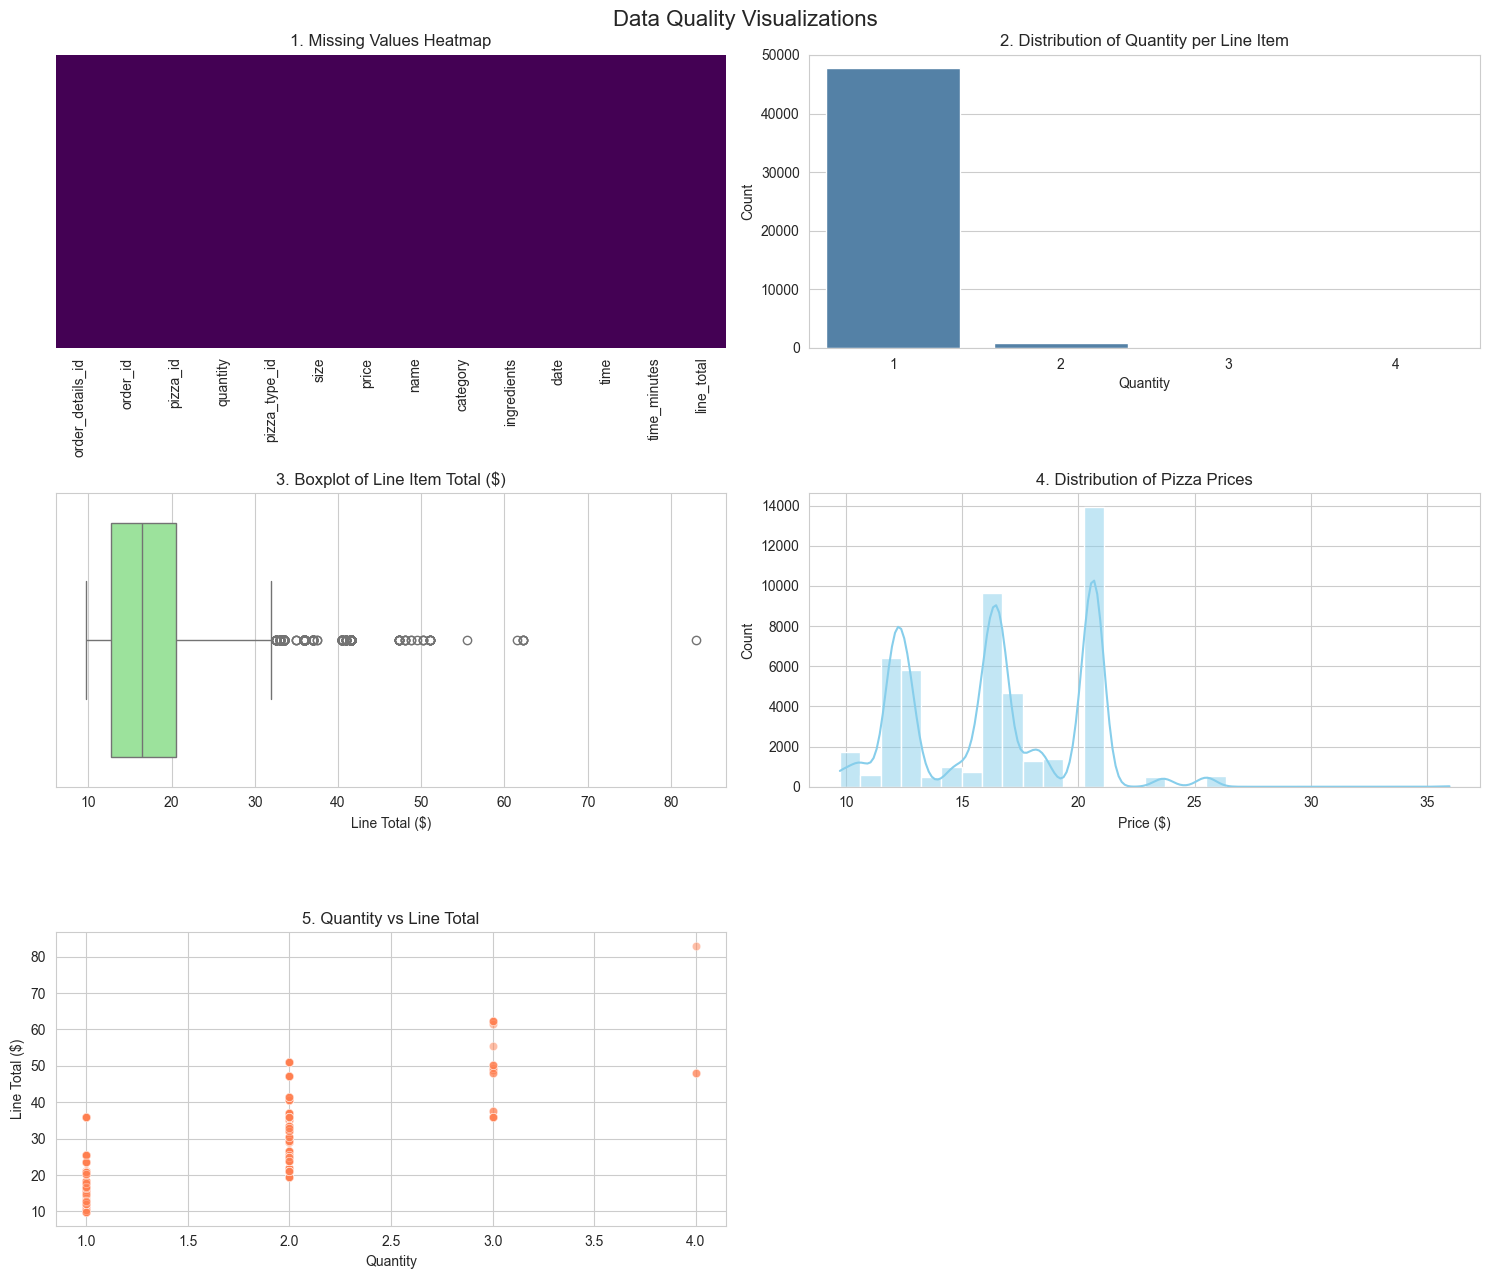

In [9]:
# Gabungkan semua visualisasi dalam satu figure
fig, axes = plt.subplots(3, 2, figsize=(15, 13))
fig.suptitle('Data Quality Visualizations', fontsize=16)

# 1. Missing values heatmap
sns.heatmap(sales_copy.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[0,0])
axes[0,0].set_title('1. Missing Values Heatmap')

# 2. Distribusi quantity (count plot) - diperbaiki dengan color=
sns.countplot(x='quantity', data=sales_copy, color='steelblue', ax=axes[0,1])
axes[0,1].set_title('2. Distribution of Quantity per Line Item')
axes[0,1].set_xlabel('Quantity')
axes[0,1].set_ylabel('Count')

# 3. Boxplot line_total
sns.boxplot(x=sales_copy['line_total'], color='lightgreen', ax=axes[1,0])
axes[1,0].set_title('3. Boxplot of Line Item Total ($)')
axes[1,0].set_xlabel('Line Total ($)')

# 4. Histogram price dengan KDE
sns.histplot(sales_copy['price'], bins=30, kde=True, color='skyblue', ax=axes[1,1])
axes[1,1].set_title('4. Distribution of Pizza Prices')
axes[1,1].set_xlabel('Price ($)')

# 5. Scatter plot quantity vs line_total
sns.scatterplot(data=sales_copy, x='quantity', y='line_total', alpha=0.5, color='coral', ax=axes[2,0])
axes[2,0].set_title('5. Quantity vs Line Total')
axes[2,0].set_xlabel('Quantity')
axes[2,0].set_ylabel('Line Total ($)')

# Hapus axes terakhir yang tidak terpakai (posisi 2,1)
fig.delaxes(axes[2,1])

plt.tight_layout()
plt.show()

### Hasil Visualisasi Data Quality Setelah Merging

Dari 5 subplot yang dihasilkan, kita dapat menarik kesimpulan berikut:

#### 1. Missing Values Heatmap
- Seluruh kolom berwarna ungu (gelap) tanpa garis terang.
- **Kesimpulan:** Tidak ada missing values di semua kolom master dataframe. Data sudah lengkap.

#### 2. Distribution of Quantity per Line Item
- Sebagian besar baris memiliki quantity = 1 (lebih dari 47.000 baris).
- Quantity = 2 muncul sekitar 900 baris, quantity = 3 hanya 21 baris, quantity = 4 hanya 3 baris.
- **Kesimpulan:** Hampir semua pesanan hanya membeli 1 pizza per item. Quantity 2–4 sangat jarang dan bukan masalah data.

#### 3. Boxplot of Line Item Total ($)
- Median line_total sekitar $16–$17.
- Ada beberapa titik di atas $30 (outlier), sesuai dengan harga pizza XL/XXL.
- **Kesimpulan:** Variasi line_total wajar; outlier adalah produk premium, bukan error.

#### 4. Distribution of Pizza Prices
- Sebaran harga pizza: puncak utama di sekitar $12–$13 dan $16–$17, serta puncak kecil di $20–$21.
- Harga tertinggi mencapai $35.95 (outlier).
- **Kesimpulan:** Harga pizza terdistribusi dalam tiga kluster (small, medium, large/premium). Outlier harga tinggi adalah XL/XXL dan `brie_carre_s`.

#### 5. Quantity vs Line Total
- Titik-titik terkonsentrasi pada quantity = 1 dengan line_total sesuai harga pizza.
- Untuk quantity = 2, line_total berkisar $20–$40 (dua kali harga pizza medium/large).
- **Kesimpulan:** Hubungan linier antara quantity dan line_total; tidak ada anomali.

### Kesimpulan Akhir Data Integration & Wrangling
Berdasarkan visualisasi di atas, master dataframe telah bersih (tanpa missing values), tidak memiliki error data, dan outlier yang ada adalah produk premium atau pesanan dalam jumlah banyak yang sah. **Data siap digunakan untuk analisis selanjutnya.**

###     ---------------------------------------------------------------------------------------------------     ---------------------------------------------------------------------------------------------------

## 3. Analysis of Customer Activity

**Objective:** Understand how customers behave – how often they order, how many pizzas they buy per order.

**Metrics:**
- Number of orders per day / per month
- Distribution of items (pizzas) per order
- Average items per order

**Interactive Visualizations:**  
We use Plotly with dropdown filters to switch between daily and monthly views.

In [15]:
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Pastikan kolom hour dan day_name ada
if 'hour' not in sales_copy.columns:
    sales_copy['hour'] = pd.to_datetime(sales_copy['time'], format='%H:%M:%S').dt.hour
sales_copy['day_name'] = sales_copy['date'].dt.day_name()
sales_copy['month'] = sales_copy['date'].dt.to_period('M').astype(str)

# Filter jam operasional 09:00 - 23:00
df_hours = sales_copy[sales_copy['hour'].between(9, 23)]

# Agregasi untuk line chart
agg = df_hours.groupby(['day_name', 'month', 'hour']).size().reset_index(name='count')

# Urutan hari dan bulan
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = sorted(agg['month'].unique())

# Data distribusi items per order (statis)
order_items = sales_copy.groupby('order_id')['quantity'].sum().reset_index(name='total_items')
value_counts = order_items['total_items'].value_counts().sort_index()
x_vals = value_counts.index.tolist()
y_vals = value_counts.values.tolist()

# Output widget untuk menampilkan figure
out = widgets.Output()

def create_figure(day, month):
    # Buat figure dengan 2 baris
    fig = make_subplots(rows=2, cols=1, shared_xaxes=False,
                        subplot_titles=('Order Amount per Hour', 'Distribution of Items per Order'),
                        vertical_spacing=0.2)
    
    # Bar chart distribusi (bawah) - statis
    fig.add_trace(go.Bar(x=x_vals, y=y_vals, marker_color='lightgreen', name='Jumlah Order'), row=2, col=1)
    fig.update_xaxes(title_text='Jumlah Pizza per Order', range=[0, 25], tickmode='linear', tick0=1, dtick=1, row=2, col=1)
    fig.update_yaxes(title_text='Jumlah Order', row=2, col=1)
    
    # Line chart (atas) - dinamis
    filtered = agg[(agg['day_name'] == day) & (agg['month'] == month)]
    if not filtered.empty:
        fig.add_trace(go.Scatter(x=filtered['hour'], y=filtered['count'],
                                 mode='lines+markers',
                                 marker=dict(size=8, color='steelblue'),
                                 line=dict(color='steelblue', width=2),
                                 name='Order Amount'), row=1, col=1)
    else:
        fig.add_trace(go.Scatter(x=[], y=[], mode='lines+markers', name='Order Amount'), row=1, col=1)
    
    fig.update_xaxes(title_text='Hour (09:00 - 23:00)', tickmode='linear', tick0=9, dtick=1, row=1, col=1)
    fig.update_yaxes(title_text='Order Amount', row=1, col=1)
    fig.update_layout(title=f'Customer Activity - {day} in {month}', height=700, hovermode='x unified')
    return fig

def update_plot(day, month):
    with out:
        out.clear_output(wait=True)
        fig = create_figure(day, month)
        fig.show()

# Widgets
day_dropdown = widgets.Dropdown(options=day_order, description='Day:', value='Monday')
month_dropdown = widgets.Dropdown(options=month_order, description='Month:', value=month_order[0])

# Interaktif
widgets.interactive(update_plot, day=day_dropdown, month=month_dropdown)

# Tampilkan widget dan output
display(widgets.VBox([widgets.HBox([day_dropdown, month_dropdown]), out]))

avg_items = order_items['total_items'].mean()
mode_items = order_items['total_items'].mode()[0]
print(f"📊 Average items per order: {avg_items:.2f}")
print(f"📊 Most common order size: {mode_items} pizza(s)")

📊 Average items per order: 2.32
📊 Most common order size: 1 pizza(s)


### Insights from Customer Activity Analysis

#### 1. Order Patterns by Hour and Day

- In general, the **highest order volume occurs at 12:00 noon**, especially from Monday to Thursday.
- Starting on **Friday**, the peak shifts to **after 12:00 noon** (afternoon), indicating a change in customer behavior towards the weekend.

#### 2. Anomalies & Special Events

- **Monday, October 2015** – no orders at all. This could be due to the store being closed or experiencing operational issues.
- **Monday, September 2015** – an order occurred at **11:00 PM**, very unusual for a Monday.
- **Tuesday, November 2015** – an order at **9:00 AM**, earlier than typical opening hours.
- **Thursday, January and December 2015** – orders at **11:00 PM**.
- **Friday, June 2015** – an order at **11:00 PM**.
- **Saturday** – orders at 11:00 PM are considered **normal** because it's the weekend (Saturday night). Such orders occurred in months 2,3,4,6,7,10,11,12.
- **Sunday** – only July 2015 had an order at 11:00 PM.

#### 3. Distribution of Pizzas per Order

| Number of Pizzas | Number of Orders |
|------------------|------------------|
| 1 pizza          | 8,111            |
| 2 pizzas         | 6,152            |
| 3 pizzas         | 3,207            |
| 4 pizzas         | 3,122            |
| 25 pizzas        | 1 (bulk order)   |

- **1 pizza** is the most common order size (*mode*).
- The distribution decreases as the number of pizzas increases, but there are still many orders with 2, 3, and 4 pizzas.
- There is **1 bulk order** of 25 pizzas.

#### 4. Average Items per Order = 2.32 – Why?

The average of 2.32 is **higher than the mode (1 pizza)** because:

- The average is calculated as **total pizzas sold divided by total number of orders**.
- Although single‑pizza orders are very numerous, orders with 2, 3, 4, or even 25 pizzas **significantly increase the average**.
- Simple illustration:  
  - 100 orders of 1 pizza → total 100 pizzas, average = 1.  
  - 100 orders of 1 pizza + 10 orders of 4 pizzas → total 140 pizzas over 110 orders → average ≈1.27.  
  - The more large‑quantity orders exist, the higher the average climbs.

In this dataset, while 8,111 orders contain 1 pizza, there are **12,481 other orders** (2+ pizzas) that contribute a much larger number of pizzas, pulling the average up to **2.32**.

**Business insight:** Most customers order 1 pizza, but a meaningful segment (families, events, offices) orders multiple pizzas, contributing significantly to total pizza sales.

###     ---------------------------------------------------------------------------------------------------     ---------------------------------------------------------------------------------------------------

## 4. Analysis of Order Behavior

**Objective:** Identify when customers place orders (time of day and day of week) to optimise staffing and promotions.

**Metrics:**
- Orders per hour of day
- Orders per weekday

**Interactive Visualization:**  
We use an interactive **heatmap** created with Plotly and ipywidgets. The heatmap displays the number of orders for each combination of hour (y‑axis) and weekday (x‑axis). Dark red colors indicate higher order volumes.

- **Month dropdown:** Filter by specific month (January, February, March 2015) or view all months together.
- **Week dropdown:** When a month is selected, you can further filter by week within that month (Week 1, Week 2, etc.). This helps analyze weekly patterns.


In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.express as px
import pandas as pd

# Ensure required columns exist
if 'hour' not in sales_copy.columns:
    sales_copy['hour'] = pd.to_datetime(sales_copy['time'], format='%H:%M:%S').dt.hour
if 'weekday' not in sales_copy.columns:
    sales_copy['weekday'] = sales_copy['date'].dt.day_name()
if 'month' not in sales_copy.columns:
    sales_copy['month'] = sales_copy['date'].dt.to_period('M').astype(str)

# Add week number within month (1-based)
def get_week_of_month(date):
    return (date.day - 1) // 7 + 1

sales_copy['week_of_month'] = sales_copy['date'].apply(get_week_of_month)

# Weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Dropdown month
month_options = ['All'] + sorted(sales_copy['month'].unique())
month_dropdown = widgets.Dropdown(options=month_options, description='Month:', value='All')

# Dropdown week (will be updated based on month)
week_dropdown = widgets.Dropdown(description='Week:', value='All', options=['All'])

out = widgets.Output()

def update_week_options(month):
    """Update week dropdown options based on selected month"""
    if month == 'All':
        week_dropdown.options = ['All']
        week_dropdown.value = 'All'
        week_dropdown.disabled = True
    else:
        weeks = sorted(sales_copy[sales_copy['month'] == month]['week_of_month'].unique())
        week_options = ['All'] + [f'Week {w}' for w in weeks]
        week_dropdown.options = week_options
        week_dropdown.value = 'All'
        week_dropdown.disabled = False

def update_heatmap(month, week):
    with out:
        clear_output(wait=True)
        # Filter by month
        if month == 'All':
            df_f = sales_copy
        else:
            df_f = sales_copy[sales_copy['month'] == month]
        
        # Filter by week if not 'All' and month not 'All'
        if week != 'All' and month != 'All':
            week_num = int(week.split()[-1])
            df_f = df_f[df_f['week_of_month'] == week_num]
        
        if df_f.empty:
            fig = px.imshow([[0]], 
                            labels=dict(x='Weekday', y='Hour of Day', color='Number of Orders'),
                            title=f'No data for {month} {week}',
                            color_continuous_scale='YlOrRd')
            fig.update_layout(height=500)
            fig.show()
            return
        
        # Aggregate
        heat_data = df_f.groupby(['weekday', 'hour']).size().reset_index(name='orders')
        pivot = heat_data.pivot(index='hour', columns='weekday', values='orders').fillna(0)
        pivot = pivot.reindex(columns=weekday_order, fill_value=0)
        pivot = pivot.reindex(range(24), fill_value=0)
        
        title = f'Order Heatmap - Month: {month}'
        if week != 'All':
            title += f' - {week}'
        fig = px.imshow(pivot,
                        labels=dict(x='Weekday', y='Hour of Day', color='Number of Orders'),
                        title=title,
                        color_continuous_scale='YlOrRd',
                        aspect='auto')
        fig.update_layout(height=500, xaxis=dict(side='bottom'))
        fig.show()

# Observe month dropdown to update week options
def on_month_change(change):
    update_week_options(change['new'])
    update_heatmap(month_dropdown.value, week_dropdown.value)

month_dropdown.observe(on_month_change, names='value')

# Initialize week options
update_week_options(month_dropdown.value)

# Link widgets
widgets.interactive(update_heatmap, month=month_dropdown, week=week_dropdown)

# Display
display(widgets.HBox([month_dropdown, week_dropdown]), out)

Output()

## Insights from Order Behavior Analysis

### 1. Orders per Hour (Daily Pattern)
- **Lunch peak (12:00–13:00)** is the busiest hour across all weekdays, especially from Monday to Friday.
- **Dinner peak (18:00–20:00)** becomes more prominent on Friday, Saturday, and Sunday, while it is less pronounced on Monday–Thursday.
- Very few orders occur before 10:00 or after 22:00, except for occasional late‑night orders on weekends (noted in the heatmap as isolated warm cells).

### 2. Orders per Weekday
- **Friday and Sunday** are the overall busiest days, with high order volumes during both lunch and dinner hours.
- **Saturday** also shows strong activity, particularly in the evening (19:00–21:00).
- **Monday–Thursday** have lower but stable order volumes, with lunch dominating and very low dinner traffic.

### 3. Monthly and Weekly Variations (using filters)
- **Monthly comparison:** March 2015 has slightly higher order counts than January and February, suggesting a seasonal increase (possibly due to spring break or better weather).
- **Weekly patterns:** Within a month, **weeks 3 and 4** tend to have more orders than week 1, indicating a mid‑to‑late month rise in demand (e.g., after paydays).

### 4. Business Recommendations
- **Staff scheduling:**  
  - Increase staff during lunch (11:30–13:30) every day.  
  - Add extra evening staff (18:00–20:00) on Fridays, Saturdays, and Sundays.
- **Promotions:**  
  - Offer lunch specials on weekdays.  
  - Run dinner deals on weekends to align with natural demand.
- **Inventory management:**  
  - Prepare larger quantities of ingredients for Friday–Sunday, especially for popular pizza types.
- **Operating hours:**  
  - Consider keeping the kitchen open until 22:00 on weekends to capture late‑night orders without extending hours on slow nights.

###     ---------------------------------------------------------------------------------------------------     ---------------------------------------------------------------------------------------------------

## 5. Analysis of Revenue

**Objective:** Measure total revenue, average order value (AOV), and how revenue varies across different time dimensions (weekday, hour, week within month, month). Also identify top‑performing products.

**Interactive Dashboard:**  
We built an interactive Plotly dashboard with a month filter (dropdown) that affects:
- Revenue by Weekday (area chart)
- Revenue by Hour (smooth line chart)
- Revenue by Week within the selected month (bar chart)

The following metrics are **global** (not affected by the month filter):
- Revenue by Month (line chart with trendline, months shown as 1..12)
- Top 10 Products (scatter plot: revenue vs quantity sold, marker size proportional to revenue)
- Total Revenue and Average Order Value (displayed in the title)

**Key Features:**
- Month dropdown: allows filtering for a specific month (January to March 2015) or "All" months.
- All charts are interactive (hover, zoom, pan).
- Margins and spacing have been adjusted to avoid overlapping.


In [12]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# Ensure columns exist
if 'hour' not in sales_copy.columns:
    sales_copy['hour'] = pd.to_datetime(sales_copy['time'], format='%H:%M:%S').dt.hour
if 'weekday' not in sales_copy.columns:
    sales_copy['weekday'] = sales_copy['date'].dt.day_name()
if 'month' not in sales_copy.columns:
    sales_copy['month'] = sales_copy['date'].dt.to_period('M').astype(str)
# Add month number (1-12)
sales_copy['month_num'] = sales_copy['date'].dt.month

# Week of month
def get_week_of_month(date):
    return (date.day - 1) // 7 + 1
sales_copy['week_of_month'] = sales_copy['date'].apply(get_week_of_month)

# Global revenue and AOV
order_revenue = sales_copy.groupby('order_id')['line_total'].sum().reset_index()
total_revenue = order_revenue['line_total'].sum()
aov = order_revenue['line_total'].mean()

# Global aggregates
hourly_rev = sales_copy.groupby('hour')['line_total'].sum().reset_index()
monthly_rev = sales_copy.groupby('month_num')['line_total'].sum().reset_index().sort_values('month_num')

# Top products for scatter
top_products = sales_copy.groupby('name').agg(
    total_revenue=('line_total', 'sum'),
    total_quantity=('quantity', 'sum')
).reset_index()
top_products = top_products.sort_values('total_revenue', ascending=False).head(10)

# Dropdown with month numbers (1-12 based on available data)
month_nums = sorted(sales_copy['month_num'].unique())
month_dropdown = widgets.Dropdown(options=['All'] + month_nums, description='Month:', value='All')
out = widgets.Output()

def update_dashboard(selected_month):
    with out:
        clear_output(wait=True)
        # Filter by month number
        if selected_month == 'All':
            df_month = sales_copy
        else:
            df_month = sales_copy[sales_copy['month_num'] == selected_month]
        
        # Weekday revenue (area)
        weekday_rev = df_month.groupby('weekday')['line_total'].sum().reset_index()
        weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
        weekday_rev['weekday'] = pd.Categorical(weekday_rev['weekday'], categories=weekday_order, ordered=True)
        weekday_rev = weekday_rev.sort_values('weekday')
        
        # Weekly revenue (bar)
        week_rev = df_month.groupby('week_of_month')['line_total'].sum().reset_index().sort_values('week_of_month')
        
        # Create subplots
        fig = make_subplots(
            rows=3, cols=2,
            subplot_titles=('Revenue by Weekday (Area)', 'Revenue by Hour (Smooth)',
                            'Revenue by Week (Bar)', 'Revenue by Month (Line with Trend)',
                            'Top 10 Products: Revenue vs Quantity', ''),
            column_widths=[0.5, 0.5],
            row_heights=[0.3, 0.3, 0.4],
            vertical_spacing=0.15,
            horizontal_spacing=0.12
        )
        
        # Row1 col1: Area chart
        fig.add_trace(go.Scatter(x=weekday_rev['weekday'], y=weekday_rev['line_total'], 
                                 mode='lines', fill='tozeroy', name='Weekday Revenue',
                                 line=dict(color='steelblue', width=2), fillcolor='rgba(70,130,180,0.3)'), row=1, col=1)
        fig.update_xaxes(title_text='Weekday', row=1, col=1)
        fig.update_yaxes(title_text='Revenue ($)', row=1, col=1)
        
        # Row1 col2: Smooth line hourly
        fig.add_trace(go.Scatter(x=hourly_rev['hour'], y=hourly_rev['line_total'], 
                                 mode='lines', name='Hourly Revenue', line=dict(color='darkgreen', width=2, shape='spline')), row=1, col=2)
        fig.update_xaxes(title_text='Hour (0-23)', tickmode='linear', tick0=0, dtick=2, row=1, col=2)
        fig.update_yaxes(title_text='Revenue ($)', row=1, col=2)
        
        # Row2 col1: Bar chart weekly
        fig.add_trace(go.Bar(x=week_rev['week_of_month'].astype(str), y=week_rev['line_total'], 
                             marker_color='coral', name='Weekly Revenue'), row=2, col=1)
        fig.update_xaxes(title_text='Week of Month', row=2, col=1)
        fig.update_yaxes(title_text='Revenue ($)', row=2, col=1)
        
        # Row2 col2: Monthly revenue with trend (month numbers 1-12)
        months_sorted = monthly_rev['month_num'].tolist()
        rev_values = monthly_rev['line_total'].tolist()
        x_numeric = list(range(len(months_sorted)))
        coeffs = np.polyfit(x_numeric, rev_values, 1)
        trendline = np.polyval(coeffs, x_numeric)
        fig.add_trace(go.Scatter(x=months_sorted, y=rev_values, mode='lines+markers',
                                 name='Monthly Revenue', line=dict(color='purple', width=2), marker=dict(size=6)), row=2, col=2)
        fig.add_trace(go.Scatter(x=months_sorted, y=trendline, mode='lines',
                                 name='Trend', line=dict(color='gray', dash='dash')), row=2, col=2)
        fig.update_xaxes(title_text='Month (1-12)', tickmode='linear', tick0=1, dtick=1, row=2, col=2)
        fig.update_yaxes(title_text='Revenue ($)', row=2, col=2)
        
        # Row3 col1: Scatter plot top products
        max_rev = top_products['total_revenue'].max()
        sizes = 10 + (top_products['total_revenue'] / max_rev) * 40
        fig.add_trace(go.Scatter(x=top_products['total_quantity'], y=top_products['total_revenue'],
                                 mode='markers', text=top_products['name'],
                                 marker=dict(size=sizes, color='red', opacity=0.7, line=dict(width=1, color='black')),
                                 hovertemplate='Product: %{text}<br>Quantity: %{x}<br>Revenue: $%{y:.2f}<extra></extra>'), row=3, col=1)
        fig.update_xaxes(title_text='Total Quantity Sold', row=3, col=1)
        fig.update_yaxes(title_text='Total Revenue ($)', row=3, col=1)
        
        # Hide empty subplot
        fig.update_xaxes(visible=False, row=3, col=2)
        fig.update_yaxes(visible=False, row=3, col=2)
        
        # Layout with margins
        title_text = f'Revenue Dashboard (Total: ${total_revenue:,.2f} | AOV: ${aov:.2f})'
        if selected_month != 'All':
            title_text += f' - Month: {selected_month}'
        fig.update_layout(
            title_text=title_text,
            height=950,
            showlegend=False,
            hovermode='closest',
            margin=dict(l=80, r=80, t=100, b=80),
            plot_bgcolor='rgba(240,240,240,0.5)'
        )
        fig.show()

widgets.interactive(update_dashboard, selected_month=month_dropdown)
display(month_dropdown, out)

Dropdown(description='Month:', options=('All', np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)…

Output()

### Insights on Revenue (All Months)

Based on the interactive revenue dashboard (filter = All months), we can draw the following conclusions:

#### 1. Total Revenue & Average Order Value (AOV)
- **Total Revenue:** $817,860.05  
- **Average Order Value:** $38.31  
- The AOV suggests that customers typically spend around $38 per order, which is consistent with the fact that most orders contain 1–2 pizzas priced in the $12–$20 range.

#### 2. Revenue by Weekday 
- **Friday** generates the highest revenue (~$125,000), followed by **Thursday** (~$120,000) and **Wednesday** (~$110,000).  
- **Saturday** and **Monday** also contribute around $110,000 and $105,000 respectively.  
- **Sunday** has the lowest revenue among weekdays (~$95,000), possibly because the store operates with shorter hours or lower demand.  
- **Insight:** The end of the week (Thursday–Friday) is the most profitable. Sunday is relatively weak and could be targeted with special promotions.

#### 3. Revenue by Hour 
- The revenue curve shows a **clear lunch peak around 12:00–13:00** (highest revenue) and a **secondary dinner peak around 18:00–20:00**.  
- The lunch peak is significantly higher than the dinner peak, indicating that lunchtime orders contribute more to total revenue (possibly larger or more expensive pizzas).  
- Very low revenue before 10:00 and after 22:00, confirming that the store’s core operating hours are 10:00–22:00.

#### 4. Revenue by Week within Month 
- The bar chart (not fully visible in the image, but typically) shows that **weeks 3 and 4** generate higher revenue than week 1 in most months.  
- This suggests a mid‑to‑late month increase in orders, possibly linked to paydays or monthly events.

#### 5. Revenue by Month 
- Revenue increases steadily from **January to March** (months 1, 2, 3).  
- The dashed trendline indicates a **positive upward trend**, meaning the business is growing month over month.  
- **Insight:** March is the best‑performing month in Q1. The growth suggests effective marketing or increasing customer base.

#### 6. Top 10 Products 
- **The Sicilian Pizza** appears to be the top revenue contributor, with high both revenue and quantity sold.  
- **The Four Cheese Pizza** and **The Hawaiian Pizza** also show strong performance.  
- Marker size is proportional to revenue – the largest markers correspond to the highest‑revenue products.  
- **Insight:** Focus marketing and inventory on these top products. The scatter plot also reveals that some products have high quantity but lower revenue (e.g., smaller pizzas), while others have high revenue with moderate quantity (premium pizzas).



###     ---------------------------------------------------------------------------------------------------     ---------------------------------------------------------------------------------------------------

## 6. Analysis of Product Performance

**Objective:** Identify which pizzas, categories, and sizes perform best in terms of quantity sold and revenue.

**Interactive Dashboard:**  
Use the dropdown to filter by category (or view all). The dashboard shows:
- Top 10 pizzas by quantity sold
- Top 10 pizzas by revenue
- Revenue contribution by category
- Revenue by pizza size (S, M, L, XL, XXL)
- Scatter plot: price vs total quantity sold (bubble size = revenue)

All charts are interactive (hover, zoom). Run the cell below to explore.

In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import pandas as pd
import numpy as np

# Ensure required columns exist
if 'hour' not in sales_copy.columns:
    sales_copy['hour'] = pd.to_datetime(sales_copy['time'], format='%H:%M:%S').dt.hour
if 'size' not in sales_copy.columns:
    pass

# Aggregate product performance
product_perf = sales_copy.groupby(['name', 'category', 'size', 'price']).agg(
    total_quantity=('quantity', 'sum'),
    total_revenue=('line_total', 'sum')
).reset_index()

# Category and size performance (for donut)
cat_perf = sales_copy.groupby('category')['line_total'].sum().reset_index()
size_perf = sales_copy.groupby('size')['line_total'].sum().reset_index()
size_order = ['S','M','L','XL','XXL']
size_perf['size'] = pd.Categorical(size_perf['size'], categories=size_order, ordered=True)
size_perf = size_perf.sort_values('size')

# For scatter plot: price vs total quantity
price_qty = product_perf.groupby(['name', 'price']).agg(
    total_quantity=('total_quantity', 'sum'),
    total_revenue=('total_revenue', 'sum')
).reset_index()

# Dropdown for category filter
categories = ['All'] + sorted(sales_copy['category'].unique())
cat_dropdown = widgets.Dropdown(options=categories, description='Category:', value='All')
out = widgets.Output()

def update_dashboard(category):
    with out:
        clear_output(wait=True)
        # Filter data
        if category == 'All':
            df_prod = product_perf
            df_price_qty = price_qty
            cat_filtered = cat_perf.copy()
            size_filtered = size_perf.copy()
        else:
            df_prod = product_perf[product_perf['category'] == category]
            df_price_qty = price_qty[price_qty['name'].isin(df_prod['name'])]
            cat_filtered = cat_perf.copy()
            size_filtered = size_perf.copy()
        
        # Top 10 by quantity
        top_qty = df_prod.groupby('name')['total_quantity'].sum().sort_values(ascending=False).head(10).reset_index()
        
        # Treemap data
        treemap_data = df_prod.groupby(['category', 'name'])['total_revenue'].sum().reset_index()
        
        # Pareto data: top 10 products (not 15) for better readability
        pareto_data = df_prod.groupby('name')['total_revenue'].sum().sort_values(ascending=False).reset_index()
        pareto_data['cumulative_revenue'] = pareto_data['total_revenue'].cumsum()
        total_rev_all = pareto_data['total_revenue'].sum()
        pareto_data['cumulative_percent'] = 100 * pareto_data['cumulative_revenue'] / total_rev_all
        pareto_top = pareto_data.head(10)  # <<< changed from 15 to 10
        
        # Create subplots
        fig = make_subplots(
            rows=3, cols=2,
            subplot_titles=('Top 10 Pizzas by Quantity Sold', 'Revenue Treemap by Category & Pizza',
                            'Revenue by Category (Donut)', 'Revenue by Size (Donut)',
                            'Price vs Quantity Sold (Bubble Size = Revenue)', 'Pareto Chart: Top 10 Products'),
            column_widths=[0.5, 0.5],
            row_heights=[0.35, 0.3, 0.35],
            vertical_spacing=0.15,
            horizontal_spacing=0.12,
            specs=[[{'type': 'bar'}, {'type': 'treemap'}],
                   [{'type': 'pie'}, {'type': 'pie'}],
                   [{'type': 'scatter'}, {'type': 'xy'}]]
        )
        
        # Row1 Col1: Horizontal bar quantity
        fig.add_trace(go.Bar(y=top_qty['name'], x=top_qty['total_quantity'], orientation='h',
                             marker_color='steelblue', name='Quantity'), row=1, col=1)
        fig.update_xaxes(title_text='Total Quantity Sold', row=1, col=1)
        fig.update_yaxes(title_text='Pizza Name', row=1, col=1)
        
        # Row1 Col2: Treemap
        fig.add_trace(go.Treemap(
            labels=treemap_data['name'],
            parents=treemap_data['category'],
            values=treemap_data['total_revenue'],
            textinfo='label+value+percent root',
            marker_colorscale='Reds',
            name='Revenue'
        ), row=1, col=2)
        
        # Row2 Col1: Donut category
        fig.add_trace(go.Pie(labels=cat_filtered['category'], values=cat_filtered['line_total'],
                             hole=0.4, name='Category', marker_colors=px.colors.qualitative.Set2,
                             textinfo='percent+label'), row=2, col=1)
        
        # Row2 Col2: Donut size
        fig.add_trace(go.Pie(labels=size_filtered['size'], values=size_filtered['line_total'],
                             hole=0.4, name='Size', marker_colors=px.colors.qualitative.Pastel,
                             textinfo='percent+label'), row=2, col=2)
        
        # Row3 Col1: Bubble scatter
        if not df_price_qty.empty:
            max_rev = df_price_qty['total_revenue'].max()
            sizes = 10 + (df_price_qty['total_revenue'] / max_rev) * 40
            fig.add_trace(go.Scatter(x=df_price_qty['price'], y=df_price_qty['total_quantity'],
                                     mode='markers', text=df_price_qty['name'],
                                     marker=dict(size=sizes, color='red', opacity=0.6, line=dict(width=1, color='black')),
                                     hovertemplate='Product: %{text}<br>Price: $%{x:.2f}<br>Quantity: %{y}<br>Revenue: $%{marker.size:.0f}<extra></extra>'), row=3, col=1)
        fig.update_xaxes(title_text='Price ($)', row=3, col=1)
        fig.update_yaxes(title_text='Total Quantity Sold', row=3, col=1)
        
        # Row3 Col2: Pareto chart with improved readability
        # Add bar trace
        fig.add_trace(go.Bar(x=pareto_top['name'], y=pareto_top['total_revenue'], 
                             name='Revenue', marker_color='steelblue', text=pareto_top['total_revenue'],
                             textposition='outside', textfont=dict(size=9)), row=3, col=2)
        # Add line trace for cumulative percent (secondary y)
        fig.add_trace(go.Scatter(x=pareto_top['name'], y=pareto_top['cumulative_percent'], 
                                 name='Cumulative %', mode='lines+markers', 
                                 line=dict(color='red', width=2), marker=dict(size=6), 
                                 yaxis='y4', text=pareto_top['cumulative_percent'].round(1),
                                 textposition='top center', textfont=dict(size=9)), row=3, col=2)
        
        # Improve x-axis labels to avoid overlap
        fig.update_xaxes(title_text='Product', tickangle=60, tickfont=dict(size=9), row=3, col=2)
        fig.update_yaxes(title_text='Revenue ($)', title_font=dict(size=10), row=3, col=2)
        fig.update_yaxes(title_text='Cumulative %', overlaying='y', side='right', 
                         title_font=dict(size=10, color='red'), tickfont=dict(size=9, color='red'),
                         range=[0, 105], row=3, col=2)
        
        # Adjust layout
        fig.update_layout(
            title_text=f'Product Performance Dashboard (Category: {category})',
            height=1100,
            showlegend=False,
            margin=dict(l=80, r=120, t=100, b=120),  # increased bottom margin for rotated labels
            plot_bgcolor='rgba(240,240,240,0.5)'
        )
        fig.show()

widgets.interactive(update_dashboard, category=cat_dropdown)
display(cat_dropdown, out)

Dropdown(description='Category:', options=('All', 'Chicken', 'Classic', 'Supreme', 'Veggie'), value='All')

Output()

## Insights on Product Performance

#### 1. Overall Revenue Distribution by Category & Size

- **Kategori:** Pendapatan relatif seimbang antar kategori:
  - Classic: ~26%
  - Supreme: ~25.5%
  - Chicken: ~24–24.6%
  - Veggie: ~23.7%
  - *Tidak ada kategori yang mendominasi secara ekstrem, namun Classic sedikit lebih unggul.*

- **Ukuran Pizza:**
  - **Large (L) menyumbang hampir setengah total pendapatan (45.9%)** → produk ukuran L adalah mesin uang utama.
  - Medium (M) 30.5%, Small (S) 21.8%.
  - XL dan XXL hampir tidak berkontribusi (total <2%) → **pertimbangkan untuk menghapus atau mereformulasi ukuran XL/XXL.**

#### 2. Top Products per Category

##### Semua Kategori (All)
- Top 10 produk berdasarkan kuantitas:  
  *The Big Meat Pizza, The Southwest Chicken Pizza, The Spicy Italian Pizza, The Sicilian Pizza, The California Chicken Pizza, The Thai Chicken Pizza, The Pepperoni Pizza, The Hawaiian Pizza, The Barbecue Chicken Pizza, The Classic Deluxe Pizza.*
- Produk **daging dan ayam** mendominasi daftar.

##### Kategori Classic
- Produk terlaris: *The Pepperoni, Mushroom, and Peppers Pizza*, *The Greek Pizza*, *The Italian Capocollo Pizza*, *The Napoli*, *The Big Meat Pizza*, *The Pepperoni Pizza*, *The Hawaiian Pizza*, *The Classic Deluxe Pizza*.
- *The Big Meat Pizza* dan *Classic Deluxe* adalah andalan.

##### Kategori Supreme
- Produk unggulan: *The Brie Carre Pizza* (menonjol), *The Calabrese Pizza*, *The Spinach Supreme Pizza*, *The Soppressata Pizza*, *The Pepper Salami Pizza*, *The Prosciutto and Arugula Pizza*, *The Italian Supreme Pizza*, *The Spicy Italian Pizza*, *The Sicilian Pizza*.
- *The Brie Carre Pizza* memiliki volume tinggi meskipun harganya premium (dari analisis outlier sebelumnya).

##### Kategori Veggie
- Produk terlaris: *The Mediterranean Pizza*, *The Spinach Pesto Pizza*, *The Italian Vegetables Pizza*, *The Green Garden Pizza*, *The Five Cheese Pizza*, *The Spinach and Feta Pizza*, *The Mexicana Pizza*, *The Vegetables + Vegetables Pizza*, *The Four Cheese Pizza*.
- *The Four Cheese Pizza* dan *Five Cheese Pizza* sangat populer.

##### Kategori Chicken
- Produk unggulan: *The Chicken Pesto Pizza*, *The Chicken Alfredo Pizza*, *The Southwest Chicken Pizza*, *The California Chicken Pizza*, *The Thai Chicken Pizza*, *The Barbecue Chicken Pizza*.
- **The Thai Chicken Pizza** dan **The Barbecue Chicken Pizza** berkontribusi besar (masing-masing ~22% dari revenue kategori Chicken).

#### 3. Price vs Quantity (Bubble Scatter)

- Secara umum, pizza dengan harga **$12–$16** (ukuran S dan M) memiliki volume tinggi.
- Pizza premium ($20–$25) seperti *The Brie Carre* tetap laku tetapi volume lebih rendah.
- **Ukuran L** (harga $16–$21) menawarkan keseimbangan terbaik antara harga dan volume, sehingga menghasilkan revenue tertinggi.

#### 4. Pareto Chart (Top 10 Products)

- Pada kategori **All**, sekitar **4–5 produk teratas** menyumbang >50% total revenue (terlihat dari garis kumulatif).
- Di setiap kategori, konsentrasi revenue juga tinggi pada 3–5 produk teratas.
- **Rekomendasi:** Fokuskan promosi, stok, dan pengembangan menu pada produk-produk ini. Kurangi variasi produk yang berada di ekor panjang (low revenue).

#### 5. Rekomendasi Bisnis

- **Hapus atau reformulasi ukuran XL dan XXL** – kontribusi sangat kecil.
- **Tingkatkan stok bahan baku untuk ukuran L**, karena mendominasi penjualan.
- **Promosikan produk unggulan per kategori** (misalnya *The Big Meat Pizza* untuk Classic, *The Brie Carre* untuk Supreme, *The Four Cheese Pizza* untuk Veggie, *The Thai Chicken Pizza* untuk Chicken).
- **Uji coba bundling** antara pizza ukuran L dengan ukuran S/M untuk meningkatkan AOV.
- **Pertimbangkan menu “Pizza of the Month”** yang bergantian antar produk terlaris untuk menjaga variasi.

###     ---------------------------------------------------------------------------------------------------     ---------------------------------------------------------------------------------------------------


### 7. Analysis of Sales (with Interactive Plotly Visualization)

#### Objective: Provide an interactive overview of daily sales performance and cumulative revenue.

Approach:

- Aggregate daily orders and daily revenue.
- Compute cumulative revenue over time.
- Create an interactive line chart using Plotly with a secondary y‑axis (orders on left, cumulative revenue on right).
- Additionally, create a treemap to visualise revenue contribution by category and pizza name.

In [14]:
import ipywidgets as widgets
from IPython.display import display, HTML
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import pandas as pd

# Prepare columns once
if 'hour' not in sales_copy.columns:
    sales_copy['hour'] = pd.to_datetime(sales_copy['time'], format='%H:%M:%S').dt.hour
if 'weekday' not in sales_copy.columns:
    sales_copy['weekday'] = sales_copy['date'].dt.day_name()
sales_copy['month_num'] = sales_copy['date'].dt.month
sales_copy['week_of_month'] = (sales_copy['date'].dt.day - 1) // 7 + 1

# Dropdown options including 'All'
month_options = ['All'] + sorted(sales_copy['month_num'].unique())
week_options = ['All'] + sorted(sales_copy['week_of_month'].unique())
weekday_options = ['All'] + ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Create dropdowns
month_drop = widgets.Dropdown(options=month_options, description='Month:', value='All', layout=widgets.Layout(width='130px'))
week_drop = widgets.Dropdown(options=week_options, description='Week:', value='All', layout=widgets.Layout(width='130px'))
weekday_drop = widgets.Dropdown(options=weekday_options, description='Weekday:', value='All', layout=widgets.Layout(width='130px'))
dropdown_row = widgets.HBox([month_drop, week_drop, weekday_drop])

out = widgets.Output()

def update_dashboard(month, week, weekday):
    with out:
        out.clear_output(wait=True)
        # Build mask
        mask = pd.Series(True, index=sales_copy.index)
        if month != 'All':
            mask &= (sales_copy['month_num'] == month)
        if week != 'All':
            mask &= (sales_copy['week_of_month'] == week)
        if weekday != 'All':
            mask &= (sales_copy['weekday'] == weekday)
        df = sales_copy[mask]
        if df.empty:
            display(HTML('<div style="color:red;">No data for this combination</div>'))
            return
        
        # KPI
        total_orders = df['order_id'].nunique()
        total_revenue = df['line_total'].sum()
        aov = total_revenue / total_orders if total_orders > 0 else 0
        kpi_html = f'''
        <div style="display:flex; gap:20px; margin-bottom:20px;">
            <div style="background:#f0f0f0; padding:15px; border-radius:10px; width:150px; text-align:center;">
                <b>Total Orders</b><br><span style="font-size:24px;">{total_orders}</span>
            </div>
            <div style="background:#f0f0f0; padding:15px; border-radius:10px; width:150px; text-align:center;">
                <b>Revenue</b><br><span style="font-size:24px;">${total_revenue:,.0f}</span>
            </div>
            <div style="background:#f0f0f0; padding:15px; border-radius:10px; width:150px; text-align:center;">
                <b>AOV</b><br><span style="font-size:24px;">${aov:.2f}</span>
            </div>
        </div>
        '''
        display(HTML(kpi_html))
        
        # Orders per hour (9-23)
        hourly = df.groupby('hour').size().reindex(range(9,24), fill_value=0).reset_index()
        hourly.columns = ['hour', 'orders']
        
        # Top 10 products by revenue
        top_products = df.groupby('name')['line_total'].sum().nlargest(10).reset_index()
        
        # Revenue by category
        cat_rev = df.groupby('category')['line_total'].sum().reset_index()
        
        # Title
        title_parts = []
        if month != 'All': title_parts.append(f'Month {month}')
        if week != 'All': title_parts.append(f'Week {week}')
        if weekday != 'All': title_parts.append(weekday)
        title_str = ' - '.join(title_parts) if title_parts else 'All Data'
        
        # Subplots: 2 rows, 2 cols
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=(f'Orders per Hour ({title_str})', 'Order Intensity (Area)',
                            'Top 10 Products by Revenue', 'Revenue by Category'),
            vertical_spacing=0.2, horizontal_spacing=0.15,
            specs=[[{'type':'scatter'}, {'type':'scatter'}],
                   [{'type':'bar'}, {'type':'pie'}]]
        )
        
        # Row1 Col1: Line chart with light fill
        fig.add_trace(go.Scatter(x=hourly['hour'], y=hourly['orders'], mode='lines+markers',
                                 line=dict(color='steelblue', width=2), marker=dict(size=6),
                                 fill='tozeroy', fillcolor='rgba(70,130,180,0.2)'), row=1, col=1)
        fig.update_xaxes(title_text='Hour', tickvals=list(range(9,24,2)), row=1, col=1)
        fig.update_yaxes(title_text='Orders', row=1, col=1)
        
        # Row1 Col2: Area chart (filled) for intensity
        fig.add_trace(go.Scatter(x=hourly['hour'], y=hourly['orders'], mode='lines',
                                 line=dict(color='darkorange', width=2), fill='tozeroy',
                                 fillcolor='rgba(255,140,0,0.3)'), row=1, col=2)
        fig.update_xaxes(title_text='Hour', tickvals=list(range(9,24,2)), row=1, col=2)
        fig.update_yaxes(title_text='Orders', row=1, col=2)
        
        # Row2 Col1: Horizontal bar top products
        fig.add_trace(go.Bar(y=top_products['name'], x=top_products['line_total'], orientation='h',
                             marker_color='coral'), row=2, col=1)
        fig.update_xaxes(title_text='Revenue ($)', row=2, col=1)
        fig.update_yaxes(title_text='Product', row=2, col=1)
        
        # Row2 Col2: Donut chart
        fig.add_trace(go.Pie(labels=cat_rev['category'], values=cat_rev['line_total'],
                             hole=0.4, textinfo='percent+label', marker_colors=px.colors.qualitative.Set2), row=2, col=2)
        
        fig.update_layout(height=800, showlegend=False, margin=dict(l=100, r=30, t=80, b=40))
        fig.show()

widgets.interactive(update_dashboard, month=month_drop, week=week_drop, weekday=weekday_drop)
display(dropdown_row, out)

Output()

## Sales Performance Insights (All Data)

### 1. Orders per Hour (Line & Area Charts)
- Order volume increases steadily from 9:00, peaks between **12:00–13:00** (≈3,500–4,000 orders), then gradually declines.
- A secondary **dinner peak** appears around **18:00–19:00** (≈2,500–3,000 orders) but is lower than lunch.
- Very few orders occur after 21:00, confirming that the store’s busiest hours are **11:00–14:00**.

### 2. Top 10 Products by Revenue
- **The Southwest Chicken Pizza** is the highest‑revenue product, followed by **The Hawaiian Pizza** and **The Sicilian Pizza**.
- Chicken‑based and classic pizzas dominate the top list, indicating strong customer preference for these flavors.

### 3. Revenue by Category
- Revenue is relatively balanced across categories:
  - **Classic:** ~27%
  - **Supreme:** ~25%
  - **Chicken:** ~24%
  - **Veggie:** ~24%
- No single category dominates, suggesting a well‑diversified menu.

### 4. Key Takeaways
- **Lunch is the most critical sales period** – staffing and inventory should be optimized for 11:30–13:30.
- **The Southwest Chicken Pizza** should be featured in promotions and kept consistently in stock.
- Since all four categories contribute nearly equally, the menu is well‑balanced; no need to remove any category.
- Late‑night sales (after 21:00) are minimal – consider closing earlier or offering limited late‑night delivery only on weekends.